# Agent Chat UI (OSS)

Agent Chat UI는 LangGraph로 구축한 에이전트를 웹 브라우저에서 대화형으로 테스트할 수 있는 오픈소스 채팅 인터페이스입니다. LangGraph 서버와 Agent Chat UI를 연결하면, 도구 호출 과정, 멀티턴 대화, 스트리밍 응답 등을 시각적으로 확인하며 에이전트를 개발할 수 있습니다.

이 튜토리얼에서는 Tavily 검색 도구를 사용하는 ReAct 에이전트를 구축하고, `langgraph dev` 명령으로 로컬 서버를 실행한 뒤, Agent Chat UI를 연결하여 에이전트와 대화하는 전체 과정을 다룹니다.

**주요 기능:**

| 기능 | 설명 |
|:---|:---|
| 실시간 스트리밍 | SSE 기반 실시간 응답 스트리밍 |
| 도구 호출 시각화 | 에이전트의 도구 호출 과정을 단계별로 표시 |
| 스레드 관리 | 대화 기록 저장, 이름 변경, 삭제 |
| 다중 인증 | standalone, credentials, OAuth 등 4가지 인증 모드 |
| LangSmith 추적 | LangSmith 트레이스 연동으로 디버깅 지원 |
| 다크/라이트 테마 | 사용자 환경에 맞는 테마 전환 |

> 참고 문서: [LangGraph Chat UI GitHub](https://github.com/teddynote-lab/langgraph-chat-ui)

![Agent Chat UI Architecture](assets/agent-chat-ui-architecture.png)

![Chat UI Interface](assets/chat-ui-main.png)

## 환경 설정

LangGraph 에이전트를 실행하기 위해 필요한 환경을 설정합니다. `.env` 파일에서 API 키를 로드하고, LangSmith를 통해 에이전트의 실행 과정을 추적할 수 있도록 설정합니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv(override=True)
logging.langsmith("LangGraph-V1-Tutorial")

LangChain/LangSmith API Key가 설정되지 않았습니다. 참고: https://wikidocs.net/250954


## langgraph.json 설정 파일

`langgraph.json`은 LangGraph 서버의 설정 파일입니다. 이 파일은 서버가 어떤 그래프를 로드할지, 환경 변수 파일의 경로, Python 버전, 의존성 패키지 등을 정의합니다. `langgraph dev` 명령은 이 파일을 읽어 에이전트 서버를 구동합니다.

주요 설정 항목은 다음과 같습니다:

| 항목 | 설명 |
|:---|:---|
| `graphs` | 그래프 이름과 파일 경로 매핑 (예: `"agent": "./agent.py:graph"`) |
| `env` | 환경 변수 파일 경로 (`.env` 파일 위치) |
| `python_version` | 사용할 Python 버전 |
| `dependencies` | 의존성 패키지 경로 (상위 디렉토리의 `pyproject.toml` 포함) |

아래 코드는 현재 디렉토리의 `langgraph.json` 파일 내용을 확인합니다.

In [2]:
import json

# langgraph.json 파일 내용 확인
with open("langgraph.json", "r") as f:
    config = json.load(f)

print(json.dumps(config, indent=2, ensure_ascii=False))

{
  "graphs": {
    "agent": "./agent.py:graph"
  },
  "env": "../.env",
  "python_version": "3.11",
  "dependencies": [
    "..",
    "."
  ]
}


## agent.py 에이전트 정의

`agent.py`는 LangGraph 서버에서 실행할 에이전트를 정의하는 파일입니다. 이 파일에서는 `create_agent` 함수를 사용하여 Tavily 검색 도구가 연동된 ReAct 에이전트를 생성합니다.

`langgraph dev` 서버는 체크포인터를 자동으로 관리하므로, `agent.py`에서는 별도의 체크포인터를 설정하지 않습니다. 서버가 자체적으로 대화 히스토리를 유지하여 멀티턴 대화가 가능합니다.

`langgraph.json`에서 `"agent": "./agent.py:graph"` 로 지정했으므로, `agent.py` 모듈의 `graph` 변수가 서버에 로드됩니다.

아래 코드는 `agent.py` 파일의 소스 코드를 확인합니다.

In [3]:
# agent.py 소스 코드 확인
with open("agent.py", "r") as f:
    print(f.read())

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_teddynote.tools.tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver

load_dotenv(override=True)

# 모델 초기화
model = init_chat_model("claude-sonnet-4-5")

# 도구 정의: Tavily 검색 도구
tools = [TavilySearch(max_results=3)]

# 메모리 체크포인터 설정
memory = MemorySaver()

# 에이전트 그래프 생성
graph = create_agent(
    model,
    tools=tools,
    checkpointer=memory,
)



## 에이전트 로컬 테스트

LangGraph 서버에 배포하기 전에, 노트북 환경에서 에이전트가 정상적으로 동작하는지 테스트합니다. `agent.py`에서 정의한 그래프를 직접 import하여 시각화하고 실행해볼 수 있습니다.

아래 코드는 에이전트 그래프를 import하고 구조를 시각화합니다.

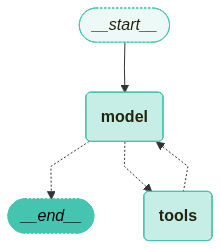

In [4]:
from agent import graph
from langchain_teddynote.graphs import visualize_graph

# 에이전트 그래프 시각화
visualize_graph(graph)

### 에이전트 실행 테스트

`stream_graph` 함수를 사용하여 에이전트에 질문을 전달하고, 도구 호출 과정과 응답을 실시간으로 확인합니다. Tavily 검색 도구가 올바르게 호출되는지, 검색 결과를 기반으로 답변이 생성되는지 검증합니다.

아래 코드는 검색이 필요한 질문을 전달하여 에이전트의 도구 호출 동작을 확인합니다.

In [5]:
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, random_uuid

# config 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 검색이 필요한 질문으로 에이전트 테스트
inputs = {"messages": [HumanMessage(content="2025년 AI 에이전트 트렌드에 대해 알려줘")]}

# 에이전트 스트리밍 실행
stream_graph(graph, inputs, config)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 



🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
[{"url": "https://brunch.co.kr/@maru7091/251", "title": "2025 AI 에이전트 트렌드 및 스타트업 전략 - 브런치", "content": "AI 에이전트는 2025년 기술 트렌드의 핵심으로 개인화된 사용자 경험, 효율성 증대, 자동화된 업무 처리에서 큰 역할을 할 것으로 예상됩니다.", "score": 0.9247491, "raw_content": "# 2025 AI 에이전트 트렌드 및 스타트업 전략\n\n스타트업\n\nAI 에이전트는 2025년 기술 트렌드의 핵심으로 개인화된 사용자 경험, 효율성 증대, 자동화된 업무 처리에서 큰 역할을 할 것으로 예상됩니다. 스타트업을 운영하면서 AI 에이전트를 활용한 비즈니스 전략을 알아보도록 합시다.\n\n## **1. AI 에이전트 트렌드 분석**\n\n![solen-feyissa-hWSNT_Pp4x4-unsplash.jpg](//img1.daumcdn.net/thumb/R1280x0.fjpg/?fname=http://t1.daumcdn.net/brunch/service/user/LOc/image/8Dsmdai_CbB7L5NjWv_uT8VzzKA.jpg)\n\n### **가. 초개인화 시대의 도래**\n\nAI에이전트는 데이터 기반의 분석과 학습을 통해 개개인에게 맞춤형 서비스를 제공합니다. 2025년에는 AI가 단순히 사용자 요구를 충족하는 것을 넘어, 예측 기반의 서비스를 제공하며 초개인화를 실현할 것입니다.\n\n### **나. 멀티모달 상호작용의 확장**\n\n### \n\n텍스트, 음성, 영상, 감정 인식까지 다양한 방식으로 사용자와 소통하는 멀티모달 AI가 주류가 될 것입니다. 이는 사용자가 플랫폼에 쉽게 적응하도록 돕고, 접근성을 대폭 확대합니다.\n\n### **다. 생성형 AI의 심화 활용**\n\nAI 에이전트가 단순히 데이터를 처리하


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2

025년 AI 에이전

트 트

...

이

 될 것으

로 전망됩니다

!

🤖✨

### 멀티턴 대화 테스트

동일한 `thread_id`를 사용하면 이전 대화 맥락을 유지한 채 후속 질문에 답변할 수 있습니다. `langgraph dev` 서버가 체크포인터를 자동으로 관리하므로, 동일 스레드 내에서 대화 히스토리가 유지됩니다.

아래 코드는 동일한 thread에서 후속 질문을 전달하여 멀티턴 대화가 정상 동작하는지 테스트합니다.

In [6]:
# 동일한 thread_id로 후속 질문 (멀티턴 대화)
inputs = {"messages": [HumanMessage(content="방금 알려준 내용을 3줄로 요약해줘")]}

# 동일한 config로 스트리밍 실행
stream_graph(graph, inputs, config)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
##

 2025년 AI 에

이전트 트

렌드 3줄 

요약

1

...

고 창

의적인 결

과물

 생산

 가능

---

## LangGraph 개발 서버 실행

에이전트가 정상적으로 동작하는 것을 확인했으므로, 이제 `langgraph dev` 명령으로 LangGraph 개발 서버를 실행합니다. 개발 서버는 에이전트를 REST API로 노출하며, Agent Chat UI와 같은 클라이언트가 이 API를 통해 에이전트와 통신합니다.

개발 서버는 기본적으로 `http://localhost:2024` 에서 실행됩니다. 코드 변경 시 자동으로 서버가 재시작되므로 개발 중에도 편리하게 사용할 수 있습니다.

아래 명령을 터미널에서 실행하세요.

```bash
cd 13-Deployment
langgraph dev --config langgraph.json
```

서버가 시작되면 `http://localhost:2024` 에서 API에 접근할 수 있습니다. 서버를 종료하려면 `Ctrl+C`를 누르세요.

---

## Agent Chat UI 설치 및 실행

[LangGraph Chat UI](https://github.com/teddynote-lab/langgraph-chat-ui)는 LangGraph 에이전트와 대화할 수 있는 웹 기반 채팅 인터페이스입니다. Next.js 15, React 19, Tailwind CSS 4, TypeScript 기반으로 구축되어 있으며, 도구 호출 시각화, 스레드 관리, 다중 인증 등 다양한 기능을 제공합니다.

설치하기 전에 다음 요구사항을 확인하세요.

| 요구사항 | 버전 |
|:---|:---|
| Node.js | v18 이상 |
| pnpm | v8 이상 |

### Node.js 설치

Node.js는 버전 관리자를 통해 설치하는 것을 권장합니다. 버전 관리자를 사용하면 프로젝트별로 다른 Node.js 버전을 쉽게 전환할 수 있고, 시스템 권한 문제 없이 패키지를 관리할 수 있습니다. 여기서는 Rust로 작성되어 빠르고 macOS/Windows 모두 지원하는 **fnm(Fast Node Manager)** 을 사용합니다.

2026년 3월 기준 Node.js LTS 버전은 **v24.x (Krypton)** 입니다.

**macOS**

```bash
# 1. fnm 설치 (Homebrew)
brew install fnm

# 2. 셸 설정 추가 (~/.zshrc 에 추가)
echo 'eval "$(fnm env --use-on-cd --shell zsh)"' >> ~/.zshrc
source ~/.zshrc

# 3. Node.js LTS 설치
fnm install --lts
fnm use lts-latest

# 4. 설치 확인
node --version
```

**Windows**

```powershell
# 1. fnm 설치 (winget)
winget install Schniz.fnm

# 2. PowerShell 프로필 설정
#    아래 명령으로 프로필 파일 열기 (없으면 자동 생성)
if (!(Test-Path -Path $PROFILE)) { New-Item -ItemType File -Path $PROFILE -Force }
notepad $PROFILE

#    프로필 파일에 아래 내용 추가 후 저장:
#    fnm env --use-on-cd --shell powershell | Out-String | Invoke-Expression

# 3. PowerShell 재시작 후 Node.js LTS 설치
fnm install --lts
fnm use lts-latest

# 4. 설치 확인
node --version
```

> 참고: [fnm GitHub](https://github.com/Schniz/fnm) | [Node.js 릴리스 일정](https://nodejs.org/en/about/previous-releases)

### pnpm 설치

pnpm은 npm보다 빠르고 디스크 효율적인 패키지 매니저입니다. 동일한 패키지를 여러 프로젝트에서 공유하는 content-addressable 저장 방식을 사용하여 설치 속도와 디스크 사용량을 크게 개선합니다. Agent Chat UI는 pnpm을 기본 패키지 매니저로 사용합니다.

2026년 3월 기준 pnpm 최신 안정 버전은 **v10.x** 입니다.

**macOS**

```bash
# 방법 1: Homebrew (권장)
brew install pnpm

# 방법 2: 독립 설치 스크립트
curl -fsSL https://get.pnpm.io/install.sh | sh -

# 설치 확인
pnpm --version
```

**Windows**

```powershell
# 방법 1: winget (권장)
winget install -e --id pnpm.pnpm

# 방법 2: PowerShell 독립 설치 스크립트
Invoke-WebRequest https://get.pnpm.io/install.ps1 -UseBasicParsing | Invoke-Expression

# 설치 확인
pnpm --version
```

> Node.js가 이미 설치되어 있다면 `npm install -g pnpm@latest-10` 으로도 설치할 수 있습니다.
>
> 참고: [pnpm 공식 설치 가이드](https://pnpm.io/installation)

### Chat UI 클론 및 실행

Node.js와 pnpm 설치가 완료되었으면, **새 터미널**에서 아래 명령을 실행하여 Chat UI를 설치하고 실행합니다.

```bash
# 1. 저장소 클론
git clone https://github.com/teddynote-lab/langgraph-chat-ui.git
cd langgraph-chat-ui

# 2. 의존성 설치
pnpm install

# 3. 대화형 설정 마법사 실행
pnpm launch
```

### pnpm launch 설정 마법사

`pnpm launch` 명령을 실행하면 대화형 설정 마법사가 시작됩니다. 마법사는 실행 모드, 인증 방식, LangGraph 서버 연결 정보 등을 단계별로 입력받아 환경을 자동으로 구성합니다. 로컬 개발 환경에서는 아래 설정을 권장합니다.

| 단계 | 설정 항목 | 권장 값 |
|:---|:---|:---|
| 1 | 실행 모드 | Development (개발 모드) |
| 2 | 인증 모드 | standalone (인증 없음, 로컬 개발용) |
| 3 | LangGraph 서버 URL | `http://localhost:2024` |
| 4 | LangSmith API 키 | (선택사항) LangSmith 추적이 필요한 경우 입력 |

설정이 완료되면 자동으로 개발 서버가 시작됩니다. 브라우저에서 `http://localhost:3000` 으로 접속하면 채팅 인터페이스를 사용할 수 있습니다.

---

## 연결 설정

`pnpm launch` 마법사를 통해 LangGraph 서버 연결 설정이 자동으로 완료됩니다. 설정된 값은 `frontend/.env` 파일에 저장되며, 앱 내에서도 Connection을 추가하거나 변경할 수 있습니다.

### 환경 변수 수동 설정

대화형 마법사 대신 `.env` 파일을 직접 편집하여 설정할 수도 있습니다. `frontend/.env.example` 파일을 복사한 후 필요한 값을 수정합니다.

```bash
cd langgraph-chat-ui/frontend
cp .env.example .env
```

로컬 개발에 필요한 최소 설정은 다음과 같습니다.

```env
# LangGraph 서버 URL
NEXT_PUBLIC_API_URL=http://localhost:2024

# 인증 모드 (standalone: 인증 없음)
AUTH_MODE=standalone
NEXT_PUBLIC_AUTH_MODE=standalone
```

환경 변수를 수정한 후 `cd frontend && pnpm dev` 명령으로 개발 서버를 실행합니다.

---

## 주요 기능 소개

LangGraph Chat UI는 단순한 채팅 인터페이스를 넘어 에이전트 개발과 운영에 필요한 다양한 기능을 제공합니다. 아래에서 각 기능을 소개합니다.

### 도구 호출 시각화

에이전트가 도구를 호출하면 호출 과정이 UI에 실시간으로 표시됩니다. 어떤 도구가 어떤 입력으로 호출되었는지, 결과는 무엇인지를 시각적으로 확인할 수 있어 에이전트의 추론 과정을 디버깅하는 데 유용합니다.

![도구 호출 시각화](assets/chat-ui-tool-call.png)

### 스레드 관리

대화를 스레드 단위로 관리할 수 있습니다. 사이드바에서 이전 대화 목록을 확인하고, 스레드 이름을 변경하거나 삭제할 수 있습니다. 각 스레드는 독립적인 `thread_id`를 가지므로, 서버 측의 `MemorySaver` 체크포인터와 연동하여 대화 히스토리가 유지됩니다.

![스레드 관리](assets/chat-ui-thread.png)

### 실시간 스트리밍

SSE(Server-Sent Events) 기반으로 에이전트의 응답이 실시간으로 스트리밍됩니다. 긴 응답을 기다리지 않고 생성되는 즉시 화면에 표시되므로, 사용자 경험이 향상됩니다.

### LangSmith 추적 연동

LangSmith API 키를 설정하면 각 대화의 실행 트레이스를 LangSmith에서 확인할 수 있습니다. 에이전트의 각 단계별 입출력, 토큰 사용량, 지연 시간 등을 분석하여 성능을 최적화할 수 있습니다.

### 다크/라이트 테마

사용자 환경에 맞게 다크 모드와 라이트 모드를 전환할 수 있습니다. 시스템 설정을 따르거나 수동으로 테마를 선택할 수 있습니다.

---

## 테스트 시나리오

Agent Chat UI에서 에이전트의 다양한 기능을 테스트해볼 수 있습니다. 아래 시나리오를 순서대로 실행하여 에이전트가 올바르게 동작하는지 확인하세요.

### 일반 대화

도구 호출 없이 모델이 직접 답변하는 일반 대화를 테스트합니다. 에이전트가 자연스러운 한국어로 응답하는지 확인합니다.

```
사용자: 안녕하세요! 오늘 날씨가 좋네요.
```

### 도구 호출 (웹 검색)

Tavily 검색 도구를 호출하여 최신 정보를 검색하고 답변하는 시나리오입니다. Chat UI에서 도구 호출 과정이 시각적으로 표시되는지 확인합니다.

```
사용자: 2025년 가장 인기 있는 AI 프레임워크는 무엇인가요?
```

### 멀티턴 대화

이전 대화 맥락을 유지한 채 후속 질문에 답변하는지 테스트합니다. `MemorySaver` 체크포인터를 통해 서버 측에서 대화 히스토리가 관리됩니다.

```
사용자: 그 중에서 LangGraph에 대해 더 자세히 알려줘
사용자: LangGraph의 장점을 3가지로 요약해줘
```

### 스레드 관리

사이드바에서 스레드 관리 기능을 테스트합니다. 새 대화를 시작하고, 이전 대화로 돌아가 맥락이 유지되는지 확인합니다.

1. 새 스레드를 생성하여 다른 주제로 대화합니다
2. 사이드바에서 이전 스레드를 선택하여 대화 기록이 유지되는지 확인합니다
3. 스레드 이름을 변경하거나 불필요한 스레드를 삭제합니다

---

## 정리

이 튜토리얼에서는 LangGraph 에이전트를 Agent Chat UI와 연동하는 전체 과정을 다루었습니다.

1. `agent.py`에서 Tavily 검색 도구를 사용하는 ReAct 에이전트를 정의했습니다
2. `langgraph.json`으로 서버 설정을 구성했습니다
3. 노트북에서 에이전트를 로컬 테스트하여 정상 동작을 확인했습니다
4. `langgraph dev` 명령으로 개발 서버를 실행했습니다
5. [LangGraph Chat UI](https://github.com/teddynote-lab/langgraph-chat-ui)를 클론하고, `pnpm launch` 마법사로 환경을 설정하여 에이전트와 대화했습니다

이 구조를 활용하면 에이전트 개발 중에 웹 UI를 통해 빠르게 테스트하고 디버깅할 수 있습니다. 에이전트의 도구를 추가하거나 프롬프트를 수정한 후 `langgraph dev` 서버가 자동으로 재시작되므로, Agent Chat UI에서 바로 변경 사항을 확인할 수 있습니다.

Production 환경에 배포하려면 LangGraph Chat UI 레포지토리의 [LangGraph 배포 가이드](https://github.com/teddynote-lab/langgraph-chat-ui/blob/main/docs/LANGGRAPH_DEPLOYMENT_GUIDE.md)를 참고하세요. LangGraph Cloud, Self-hosted, Docker 등 다양한 배포 옵션에 대한 상세한 안내를 제공합니다.

> 참고 자료:
> - [LangGraph Chat UI GitHub](https://github.com/teddynote-lab/langgraph-chat-ui)
> - [LangGraph 배포 가이드 (Production)](https://github.com/teddynote-lab/langgraph-chat-ui/blob/main/docs/LANGGRAPH_DEPLOYMENT_GUIDE.md)
> - [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)
> - [LangSmith](https://smith.langchain.com/)